In [1]:
# ══════════════════════════════════════════════════════════
# CELDA 1 — Librerías y carga de datos
# ══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/TFM_Seguridad_Vial'
outputs = f'{BASE}/outputs'

df = pd.read_csv(f'{outputs}/tabla_anual_final.csv')

print(f'Forma: {df.shape}')
print(f'Años disponibles: {sorted(df["año"].unique())}')
print(f'Distritos: {df["distrito"].nunique()}')
print(f'Nulos: {df.isnull().sum().sum()}')

Mounted at /content/drive
Forma: (126, 26)
Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Distritos: 21
Nulos: 0


In [2]:
# ══════════════════════════════════════════════════════════
# CELDA 2 — Variables derivadas
# ══════════════════════════════════════════════════════════
# Calculamos sobre el dataset completo (2019-2024)
# La normalización se hará solo sobre 2021-2024

# ── Seguridad ──────────────────────────────────────────────
# Accidentes ponderados por km²
df['acc_pond_km2'] = (df['acc_ponderado'] / df['area_km2']).round(4)

# Tasa de mortalidad: fallecidos VRU por 100.000 habitantes
df['tasa_mortalidad'] = (
    df['acc_vru_mortales'] / df['poblacion'] * 100_000
).round(4)

# Tendencia interanual — pendiente de regresión lineal (ventana 3 años deslizante)
# Usa acc_vru_total (sin ponderar) para medir dirección del cambio en volumen
# independiente de acc_pond_km2 que ya captura la gravedad actual
# Justificación: evitar correlación intra-dimensión (Nardo et al., 2008)
# 2021: usa 2019,2020,2021 | 2022: usa 2020,2021,2022 | etc.
def calcular_tendencia(df_input):
    resultados = []
    for distrito in df_input['distrito'].unique():
        d = df_input[df_input['distrito'] == distrito].sort_values('año')
        for año in [2021, 2022, 2023, 2024]:
            ventana = d[d['año'].between(año-2, año)]['acc_vru_total'].values
            if len(ventana) == 3:
                pendiente = np.polyfit([0,1,2], ventana, 1)[0]
            else:
                pendiente = np.nan
            resultados.append({
                'distrito': distrito,
                'año': año,
                'tendencia': round(float(pendiente), 4)
            })
    return pd.DataFrame(resultados)

tendencias = calcular_tendencia(df)
df = df.merge(tendencias, on=['distrito', 'año'], how='left')

print(f'Nulos en tendencia (2021-2024): '
      f'{df[df["año"].between(2021,2024)]["tendencia"].isnull().sum()}')


# ── Vulnerabilidad ─────────────────────────────────────────
# Densidad de población vulnerable por km²
df['densidad_vulnerable'] = (
    (df['poblacion'] * (df['pct_mayores_65'] + df['pct_menores_15']) / 100)
    / df['area_km2']
).round(2)

# Calculadas para uso posterior en el modelo predictivo
# No forman parte del IPD (excluidas por causalidad inversa)
df['km_carril_km2'] = (df['km_carril_bici'] / df['area_km2']).round(4)
df['densidad_peatonal'] = (df['poblacion'] / df['area_km2']).round(2)

# ── Resumen ────────────────────────────────────────────────
vars_derivadas = [
    'acc_pond_km2', 'tasa_mortalidad', 'tendencia',
    'km_carril_km2', 'densidad_peatonal', 'densidad_vulnerable'
]

print('\nEstadísticas variables derivadas (2021-2024):')
print(
    df[df['año'].between(2021,2024)][vars_derivadas]
    .describe().round(3).to_string()
)
print(f'\nNulos: {df[df["año"].between(2021,2024)][vars_derivadas].isnull().sum().to_dict()}')

Nulos en tendencia (2021-2024): 0

Estadísticas variables derivadas (2021-2024):
       acc_pond_km2  tasa_mortalidad  tendencia  km_carril_km2  densidad_peatonal  densidad_vulnerable
count        84.000           84.000     84.000         84.000             84.000               84.000
mean         15.381            0.377      3.530          3.482          14697.504             4704.180
std          14.275            0.526     13.051          2.641           9822.557             3114.445
min           0.652            0.000    -38.000          0.259           1035.490              390.900
25%           4.635            0.000     -3.750          1.303           7107.812             2199.448
50%          11.047            0.000      2.750          2.172          15761.490             5543.340
75%          24.324            0.650     11.125          4.902          21924.955             6726.952
max          61.377            2.056     52.000          8.784          31560.340            10

In [3]:
# ══════════════════════════════════════════════════════════
# CELDA 3 — Filtrar 2021-2024 y normalizar min-max
# ══════════════════════════════════════════════════════════

ipd = df[df['año'].between(2021, 2024)].copy().reset_index(drop=True)
print(f'Observaciones para el IPD: {len(ipd)}')  # debe ser 84

# Variables del IPD y su sentido de normalización
# True  = más alto → más riesgo (normalización directa)
# False = más alto → menos riesgo (normalización inversa)
#
# Decisiones metodológicas basadas en análisis exploratorio:
# - Infraestructura eliminada: causalidad inversa mediada por densidad urbana
# - pct_menores_15 eliminada: correlación -0.82 con acc_pond_km2 (distritos
#   jóvenes son periféricos con baja accidentalidad)
# - vel_media_vial eliminada: correlación -0.69 con densidad_peatonal
#   (mide suburbanidad, no riesgo real)
# - n_estaciones_bicimad eliminada: correlación 0.54 con acc_pond_km2
#   (mediada por densidad urbana, no aporta información independiente)
# - densidad_peatonal eliminada: correlación 0.97 con densidad_vulnerable
#   (double counting, Nardo et al. 2008 recomienda eliminar si r > 0.90)

variables_ipd = {
    # Seguridad (55%)
    'acc_pond_km2':      True,
    'tasa_mortalidad':   True,
    'tendencia':         True,
    # Vulnerabilidad (45%)
    'pct_mayores_65':    True,
    'densidad_vulnerable': True,
}

def normalizar_minmax(series, inverso=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.0, index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return (100 - norm) if inverso else norm

for var, es_riesgo in variables_ipd.items():
    col_norm = f'{var}_norm'
    ipd[col_norm] = normalizar_minmax(ipd[var], inverso=not es_riesgo)

cols_norm = [f'{v}_norm' for v in variables_ipd]
print('\nRango de variables normalizadas:')
print(ipd[cols_norm].agg(['min','max']).round(2).to_string())
print(f'\nNulos: {ipd[cols_norm].isnull().sum().sum()}')

Observaciones para el IPD: 84

Rango de variables normalizadas:
     acc_pond_km2_norm  tasa_mortalidad_norm  tendencia_norm  pct_mayores_65_norm  densidad_vulnerable_norm
min                0.0                   0.0             0.0                  0.0                       0.0
max              100.0                 100.0           100.0                100.0                     100.0

Nulos: 0


In [4]:
# ══════════════════════════════════════════════════════════
# CELDA 4 — Calcular las 2 dimensiones
# ══════════════════════════════════════════════════════════

# ── Seguridad (55%) ────────────────────────────────────────
ipd['dim_seguridad'] = (
    ipd['acc_pond_km2_norm']    * 0.40 +
    ipd['tasa_mortalidad_norm'] * 0.35 +
    ipd['tendencia_norm']       * 0.25
).round(4)

# ── Vulnerabilidad (45%) ───────────────────────────────────
ipd['dim_vulnerabilidad'] = (
    ipd['pct_mayores_65_norm']       * 0.60 +
    ipd['densidad_vulnerable_norm']  * 0.40
).round(4)

dims = ['dim_seguridad', 'dim_vulnerabilidad']
print('Rango dimensiones:')
print(ipd[dims].agg(['min','max']).round(2).to_string())
print(f'Nulos: {ipd[dims].isnull().sum().sum()}')

# Correlación entre dimensiones — deben ser independientes
print(f'\nCorrelación entre dimensiones: {ipd["dim_seguridad"].corr(ipd["dim_vulnerabilidad"]):.4f}')

Rango dimensiones:
     dim_seguridad  dim_vulnerabilidad
min           9.51                1.17
max          79.11               91.99
Nulos: 0

Correlación entre dimensiones: 0.3302


In [5]:
# ══════════════════════════════════════════════════════════
# CELDA 5 — IPD final y ranking
# ══════════════════════════════════════════════════════════

ipd['IPD'] = (
    ipd['dim_seguridad']      * 0.55 +
    ipd['dim_vulnerabilidad'] * 0.45
).round(2)

print(f'IPD — rango: {ipd["IPD"].min():.2f} – {ipd["IPD"].max():.2f}')
print(f'IPD — media: {ipd["IPD"].mean():.2f}')

# Ranking por año
print('\n=== RANKING IPD POR AÑO ===')
for año in [2021, 2022, 2023, 2024]:
    r = (
        ipd[ipd['año'] == año][['distrito','IPD'] + dims]
        .sort_values('IPD', ascending=False)
        .reset_index(drop=True)
    )
    r.index += 1
    print(f'\n── {año} ──')
    print(r[['distrito','IPD']].to_string())

# Ranking promedio 2021-2024
print('\n=== RANKING PROMEDIO 2021-2024 ===')
ranking_medio = (
    ipd.groupby('distrito')['IPD']
    .mean()
    .reset_index()
    .rename(columns={'IPD': 'IPD_medio'})
    .sort_values('IPD_medio', ascending=False)
    .reset_index(drop=True)
)
ranking_medio.index += 1
ranking_medio['IPD_medio'] = ranking_medio['IPD_medio'].round(2)
print(ranking_medio.to_string())

IPD — rango: 7.53 – 72.54
IPD — media: 37.09

=== RANKING IPD POR AÑO ===

── 2021 ──
               distrito    IPD
1              CHAMBERÍ  56.12
2                RETIRO  53.62
3             SALAMANCA  50.48
4                CENTRO  46.93
5                TETUÁN  45.98
6             MORATALAZ  42.62
7            ARGANZUELA  40.45
8             CHAMARTÍN  38.31
9         CIUDAD LINEAL  38.23
10               LATINA  36.83
11      MONCLOA-ARAVACA  34.19
12   PUENTE DE VALLECAS  31.68
13          CARABANCHEL  26.24
14           VILLAVERDE  25.41
15                USERA  24.37
16  SAN BLAS-CANILLEJAS  24.04
17  FUENCARRAL-EL PARDO  23.56
18            HORTALEZA  21.34
19              BARAJAS  16.23
20    VILLA DE VALLECAS  14.46
21            VICÁLVARO  10.31

── 2022 ──
               distrito    IPD
1             SALAMANCA  65.83
2              CHAMBERÍ  60.21
3             MORATALAZ  55.52
4                RETIRO  51.93
5                CENTRO  49.55
6         CIUDAD LINEAL  47.74
7  

In [6]:
# ══════════════════════════════════════════════════════════
# CELDA 6 — Análisis de sensibilidad de pesos
# ══════════════════════════════════════════════════════════

from scipy.stats import spearmanr

df_2024 = ipd[ipd['año'] == 2024].copy()

# IPD base con pesos 55/45
ipd_base_vals = (
    df_2024['dim_seguridad']      * 0.55 +
    df_2024['dim_vulnerabilidad'] * 0.45
)

def ipd_dos_dims(df, w_seg, w_vul):
    return df['dim_seguridad'] * w_seg + df['dim_vulnerabilidad'] * w_vul

# Escenarios: variamos cada peso ±10 puntos porcentuales
escenarios = [
    ('Seguridad +10% (65/35)',    0.65, 0.35),
    ('Seguridad +20% (75/25)',    0.75, 0.25),
    ('Seguridad -10% (45/55)',    0.45, 0.55),
    ('Seguridad -20% (35/65)',    0.35, 0.65),
    ('Igual peso (50/50)',        0.50, 0.50),
    ('Solo Seguridad (100/0)',    1.00, 0.00),
    ('Solo Vulnerabilidad (0/100)', 0.00, 1.00),
]

resultados_sens = []
for nombre, w1, w2 in escenarios:
    ipd_alt = ipd_dos_dims(df_2024, w1, w2)
    rho, _ = spearmanr(ipd_base_vals, ipd_alt)
    resultados_sens.append({
        'Escenario': nombre,
        'Rho_Spearman': round(rho, 4)
    })

df_sens = pd.DataFrame(resultados_sens)
print('=== ANÁLISIS DE SENSIBILIDAD — Spearman vs ranking base 2024 (55/45) ===')
print(df_sens.to_string(index=False))
print(f'\nMínimo rho: {df_sens["Rho_Spearman"].min():.4f}')
if df_sens["Rho_Spearman"].min() >= 0.90:
    print('✅ Índice robusto — rho ≥ 0.90 en todos los escenarios')
else:
    print('⚠️ Revisar escenarios con rho < 0.90')
    print(df_sens[df_sens['Rho_Spearman'] < 0.90])

=== ANÁLISIS DE SENSIBILIDAD — Spearman vs ranking base 2024 (55/45) ===
                  Escenario  Rho_Spearman
     Seguridad +10% (65/35)        0.9909
     Seguridad +20% (75/25)        0.9727
     Seguridad -10% (45/55)        0.9805
     Seguridad -20% (35/65)        0.9597
         Igual peso (50/50)        0.9909
     Solo Seguridad (100/0)        0.8883
Solo Vulnerabilidad (0/100)        0.8597

Mínimo rho: 0.8597
⚠️ Revisar escenarios con rho < 0.90
                     Escenario  Rho_Spearman
5       Solo Seguridad (100/0)        0.8883
6  Solo Vulnerabilidad (0/100)        0.8597


In [7]:
# ══════════════════════════════════════════════════════════
# CELDA 7 — Exportar resultados
# ══════════════════════════════════════════════════════════

dims = ['dim_seguridad', 'dim_vulnerabilidad']
cols_export = (
    ['distrito', 'año', 'IPD'] +
    dims +
    [f'{v}_norm' for v in variables_ipd] +
    list(variables_ipd.keys())
)

ipd[cols_export].to_csv(
    f'{outputs}/IPD_completo.csv',
    index=False, encoding='utf-8-sig'
)
print('✅ IPD_completo.csv guardado')

ranking_medio.to_csv(
    f'{outputs}/IPD_ranking_medio.csv',
    index=True, index_label='posicion',
    encoding='utf-8-sig'
)
print('✅ IPD_ranking_medio.csv guardado')

df_sens.to_csv(
    f'{outputs}/IPD_sensibilidad.csv',
    index=False, encoding='utf-8-sig'
)
print('✅ IPD_sensibilidad.csv guardado')

print(f'\nResumen:')
print(f'  IPD_completo.csv      → {len(ipd)} filas × {len(cols_export)} cols')
print(f'  IPD_ranking_medio.csv → 21 distritos')
print(f'  IPD_sensibilidad.csv  → {len(df_sens)} escenarios')

✅ IPD_completo.csv guardado
✅ IPD_ranking_medio.csv guardado
✅ IPD_sensibilidad.csv guardado

Resumen:
  IPD_completo.csv      → 84 filas × 15 cols
  IPD_ranking_medio.csv → 21 distritos
  IPD_sensibilidad.csv  → 7 escenarios


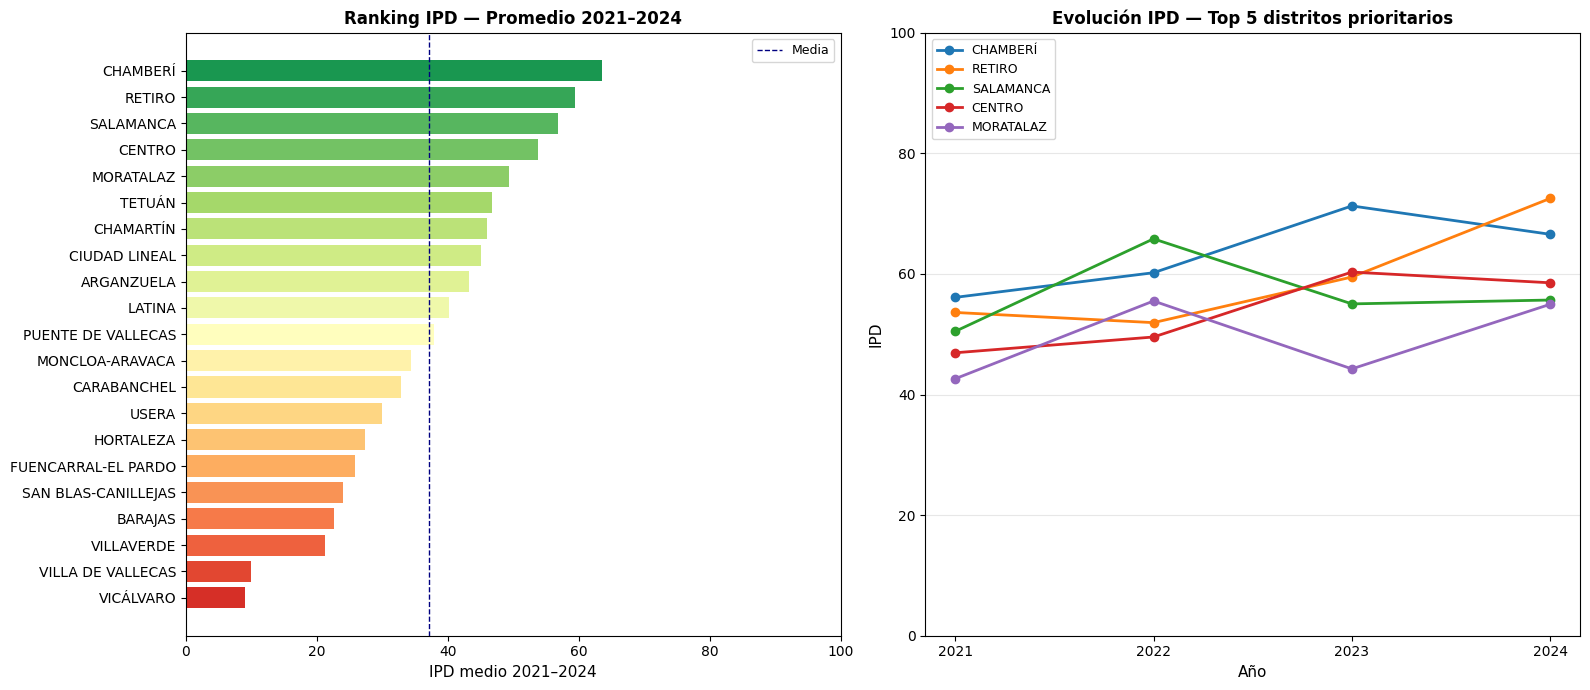

✅ IPD_ranking_visualizacion.png guardado


In [8]:
# ══════════════════════════════════════════════════════════
# CELDA 8 — Visualización rápida del ranking
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Izquierda: ranking promedio 2021-2024 ──────────────────
ax = axes[0]
colores = cm.RdYlGn_r(np.linspace(0.1, 0.9, 21))
bars = ax.barh(
    ranking_medio['distrito'][::-1],
    ranking_medio['IPD_medio'][::-1],
    color=colores[::-1]
)
ax.set_xlabel('IPD medio 2021–2024', fontsize=11)
ax.set_title('Ranking IPD — Promedio 2021–2024', fontsize=12, fontweight='bold')
ax.axvline(ranking_medio['IPD_medio'].mean(), color='navy',
           linestyle='--', linewidth=1, label='Media')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)

# ── Derecha: evolución temporal top-5 ─────────────────────
ax2 = axes[1]
top5 = ranking_medio.head(5)['distrito'].tolist()
for dist in top5:
    d = ipd[ipd['distrito'] == dist].sort_values('año')
    ax2.plot(d['año'], d['IPD'], marker='o', label=dist, linewidth=2)
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('IPD', fontsize=11)
ax2.set_title('Evolución IPD — Top 5 distritos prioritarios', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_ylim(0, 100)
ax2.set_xticks([2021, 2022, 2023, 2024])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/IPD_ranking_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ IPD_ranking_visualizacion.png guardado')

In [9]:
# Verificar valores de Chamberí y Retiro
chamberi = ipd[ipd['distrito'] == 'CHAMBERÍ'].copy()
retiro = ipd[ipd['distrito'] == 'RETIRO'].copy()

print("=== CHAMBERÍ ===")
print(chamberi[['año', 'dim_seguridad', 'dim_vulnerabilidad',
                 'pct_mayores_65', 'densidad_vulnerable',
                 'acc_pond_km2', 'area_km2']].to_string())

print("\n=== RETIRO ===")
print(retiro[['año', 'dim_seguridad', 'dim_vulnerabilidad',
              'pct_mayores_65', 'densidad_vulnerable']].to_string())

print("\n=== DIMENSIONES MEDIAS POR DISTRITO ===")
print(ipd.groupby('distrito')[['dim_seguridad', 'dim_vulnerabilidad']].mean().round(2).to_string())

=== CHAMBERÍ ===
     año  dim_seguridad  dim_vulnerabilidad  pct_mayores_65  densidad_vulnerable  acc_pond_km2  area_km2
20  2021        30.1797             87.8156           24.23             10011.98       38.0342      4.68
21  2022        36.5239             89.1523           24.42             10143.82       32.9060      4.68
22  2023        56.4973             89.3644           24.31             10312.04       35.0427      4.68
23  2024        49.2696             87.7390           23.97             10266.22       41.2393      4.68

=== RETIRO ===
     año  dim_seguridad  dim_vulnerabilidad  pct_mayores_65  densidad_vulnerable
52  2021        25.1709             88.3988           26.21              8075.70
53  2022        20.5853             90.2356           26.57              8152.94
54  2023        33.0241             91.8517           26.82              8291.04
55  2024        56.6272             91.9931           26.81              8336.61

=== DIMENSIONES MEDIAS POR DISTRITO 

In [10]:
ranking_completo = (ipd.groupby('distrito')['IPD'].mean()
    .reset_index()
    .rename(columns={'IPD': 'IPD_medio'}))
mn = ranking_completo['IPD_medio'].min()
mx = ranking_completo['IPD_medio'].max()
ranking_completo['IPD_norm'] = ((ranking_completo['IPD_medio'] - mn) / (mx - mn) * 100).round(2)
ranking_completo = ranking_completo.sort_values('IPD_norm', ascending=False).reset_index(drop=True)
ranking_completo.index += 1
ranking_completo.index.name = 'posicion'
ranking_completo.to_csv(f'{outputs}/IPD_ranking_completo.csv', encoding='utf-8-sig')
print(ranking_completo.to_string())

                     distrito  IPD_medio  IPD_norm
posicion                                          
1                    CHAMBERÍ    63.5500    100.00
2                      RETIRO    59.3975     92.39
3                   SALAMANCA    56.7575     87.55
4                      CENTRO    53.8350     82.19
5                   MORATALAZ    49.3450     73.95
6                      TETUÁN    46.6875     69.08
7                   CHAMARTÍN    45.9375     67.71
8               CIUDAD LINEAL    45.0200     66.02
9                  ARGANZUELA    43.2125     62.71
10                     LATINA    40.1325     57.06
11         PUENTE DE VALLECAS    37.8400     52.86
12            MONCLOA-ARAVACA    34.3650     46.49
13                CARABANCHEL    32.8650     43.74
14                      USERA    29.9050     38.31
15                  HORTALEZA    27.3025     33.54
16        FUENCARRAL-EL PARDO    25.8750     30.92
17        SAN BLAS-CANILLEJAS    24.0125     27.51
18                    BARAJAS  

In [11]:
chamberi = ipd[ipd['distrito'] == 'CHAMBERÍ']
print(f"densidad_vulnerable media: {chamberi['densidad_vulnerable'].mean():.0f}")
print(f"acc_pond_km2 media: {chamberi['acc_pond_km2'].mean():.1f}")
print(f"pct_mayores_65 media: {chamberi['pct_mayores_65'].mean():.1f}%")
print(f"area_km2: {chamberi['area_km2'].mean():.2f}")

densidad_vulnerable media: 10184
acc_pond_km2 media: 36.8
pct_mayores_65 media: 24.2%
area_km2: 4.68
